# Fine-tuning a Japanese text labeller (LoRA, multi-label)

This notebook fine-tunes `ku-nlp/deberta-v3-base-japanese` to classify Diet
(国会) speech segments into rhetorical categories (質問文, 答弁文, 意見文, ...).

The pipeline follows standard best practices for multi-label LoRA fine-tuning:

1. **Clean + vectorise** the raw labels into multi-hot vectors.
2. **Stratified train / validation / test split** (multi-label aware).
3. **LoRA** parameter-efficient fine-tuning with a class-weighted BCE loss.
4. **Model selection on validation**, **per-class threshold tuning**, and a
   final **held-out test** evaluation with per-class and confusion **heatmaps**.

## 1. Clean the raw labels into a multi-label format

In [1]:
import os
import csv
import json
import re
from collections import Counter

from params.paths import DATA_DIR

# Canonical label set (index order is the model's output order).
PARLIAMENT_SPEECH_LABELS = [
    "質問文", "追及・確認文", "答弁文", "反論・再反論文", "意見文",
    "要望・提案文", "批判文", "評価文", "説明文", "事実文",
    "謝罪・釈明文", "手続・運営文", "その他",
]

# A handful of raw labels are obvious typos/variants of canonical labels and
# can be safely remapped. Everything else outside the canonical set (e.g. LLM
# error strings that leaked into the data) is dropped.
LABEL_ALIASES = {
    "釈明文": "謝罪・釈明文",
    "釈明・謝罪文": "謝罪・釈明文",
    "釈明・釈明文": "謝罪・釈明文",
}

# Labels may be joined by "、" with a few stray comma variants in the raw data.
_LABEL_SPLIT_RE = re.compile(r"[、,，]")

DIET_RAW_CSV = os.path.join(DATA_DIR, "diet_speech_label", "segment_diet_speech_label.csv")
DIET_PROCESSED_PATH = os.path.join(DATA_DIR, "diet_speech_label", "vector_label_diet_speech_label.jsonl")


def _parse_labels(raw_label):
    """Split a raw multi-label string into deduplicated canonical labels."""
    labels = []
    for part in _LABEL_SPLIT_RE.split(raw_label or ""):
        name = LABEL_ALIASES.get(part.strip(), part.strip())
        if name in PARLIAMENT_SPEECH_LABELS and name not in labels:
            labels.append(name)
    return labels


def convert_diet_csv_to_vectors(raw_csv=DIET_RAW_CSV, out_path=DIET_PROCESSED_PATH):
    """Read the tab-separated Diet speech CSV and write a cleaned multi-hot
    JSONL ({text, label, text_label}). Rows with empty text or no valid label
    after cleaning are dropped."""
    label_to_idx = {lab: i for i, lab in enumerate(PARLIAMENT_SPEECH_LABELS)}
    kept, dropped = 0, 0
    label_counts = Counter()

    with open(raw_csv, encoding="utf-8") as f_in, open(out_path, "w", encoding="utf-8") as f_out:
        for row in csv.DictReader(f_in, delimiter="\t"):
            text = (row.get("Speech") or "").strip()
            labels = _parse_labels(row.get("Label", ""))
            if not text or not labels:
                dropped += 1
                continue
            vector = [0] * len(PARLIAMENT_SPEECH_LABELS)
            for lab in labels:
                vector[label_to_idx[lab]] = 1
                label_counts[lab] += 1
            f_out.write(json.dumps(
                {"text": text, "label": vector, "text_label": labels},
                ensure_ascii=False,
            ) + "\n")
            kept += 1

    print(f"Wrote {kept} examples to {out_path} (dropped {dropped} invalid rows).")
    for lab in PARLIAMENT_SPEECH_LABELS:
        print(f"  {lab}: {label_counts[lab]}")
    return out_path


convert_diet_csv_to_vectors()

Wrote 7991 examples to /root/projects/kokkai_analysis/data/params/../data/diet_speech_label/vector_label_diet_speech_label.jsonl (dropped 58 invalid rows).
  質問文: 954
  追及・確認文: 1596
  答弁文: 843
  反論・再反論文: 320
  意見文: 2854
  要望・提案文: 1202
  批判文: 1135
  評価文: 417
  説明文: 2633
  事実文: 1718
  謝罪・釈明文: 105
  手続・運営文: 960
  その他: 115


'/root/projects/kokkai_analysis/data/params/../data/diet_speech_label/vector_label_diet_speech_label.jsonl'

## 2. Setup: imports, config and LoRA settings

In [2]:
import os
import json
import random
import datetime
from collections import Counter

import numpy as np
import torch
import matplotlib.pyplot as plt
import japanize_matplotlib  # noqa: F401  registers Japanese fonts for matplotlib

from datasets import Dataset, DatasetDict, Sequence, Value
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
)
from peft import LoraConfig, get_peft_model, TaskType
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    average_precision_score, classification_report,
)

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Core config
MODEL_NAME = "ku-nlp/deberta-v3-base-japanese"
MAX_LEN = 256
OUTPUT_DIR = os.path.join(DATA_DIR, "finetuned_text_labeller_parliament")
SPLIT_FRACTIONS = {"train": 0.8, "validation": 0.1, "test": 0.1}

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
USE_FP16 = torch.cuda.is_available()
print(f"Device: {DEVICE} | fp16: {USE_FP16}")

# LoRA: adapt the attention projections + FFN, fully train the new head.
LORA_CONFIG = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=16,
    lora_alpha=32,
    lora_dropout=0.1,
    target_modules=["query_proj", "key_proj", "value_proj", "intermediate.dense", "output.dense"],
    modules_to_save=["classifier", "pooler"],
    bias="none",
)

/root/projects/kokkai_analysis/data/data_venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda | fp16: True


## 3. Visualisation and evaluation helpers

In [3]:
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))


def as_multihot(y):
    """Coerce labels to an int {0,1} array of shape [N, L]."""
    return (np.asarray(y) > 0.5).astype(np.int64)


def compute_multilabel_metrics(probs, y_true, thresholds=0.5):
    """Standard multi-label metrics for given probabilities + thresholds."""
    y_true = as_multihot(y_true)
    preds = (probs >= np.asarray(thresholds)).astype(np.int32)
    metrics = {
        "f1_micro": f1_score(y_true, preds, average="micro", zero_division=0),
        "f1_macro": f1_score(y_true, preds, average="macro", zero_division=0),
        "f1_weighted": f1_score(y_true, preds, average="weighted", zero_division=0),
        "precision_micro": precision_score(y_true, preds, average="micro", zero_division=0),
        "recall_micro": recall_score(y_true, preds, average="micro", zero_division=0),
        "pr_auc_macro": average_precision_score(y_true, probs, average="macro"),
    }
    return metrics, preds


def tune_thresholds(probs, y_true, grid=np.linspace(0.05, 0.95, 19)):
    """Per-class threshold that maximises each class's F1 on the given set.
    Run this on VALIDATION only, then apply to test."""
    y_true = as_multihot(y_true)
    best = np.full(y_true.shape[1], 0.5)
    for c in range(y_true.shape[1]):
        best_f1 = -1.0
        for t in grid:
            f1 = f1_score(y_true[:, c], (probs[:, c] >= t).astype(int), zero_division=0)
            if f1 > best_f1:
                best_f1, best[c] = f1, t
    return best


def _heatmap(mat, row_labels, col_labels, title, fmt="{:.2f}", cmap="viridis", vmin=None, vmax=None):
    fig, ax = plt.subplots(figsize=(max(8, len(col_labels) * 0.9), max(6, len(row_labels) * 0.55)))
    im = ax.imshow(mat, aspect="auto", cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_xticks(range(len(col_labels)), col_labels, rotation=45, ha="right")
    ax.set_yticks(range(len(row_labels)), row_labels)
    thresh = (np.nanmax(mat) + np.nanmin(mat)) / 2 if mat.size else 0
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            ax.text(j, i, fmt.format(mat[i, j]), ha="center", va="center",
                    color="white" if mat[i, j] < thresh else "black", fontsize=8)
    ax.set_title(title)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    fig.tight_layout()
    plt.show()


def plot_label_distribution(y, labels, title="Label distribution", log_y=False):
    """Bar plot of how many examples carry each label (multi-label friendly)."""
    y = as_multihot(y)
    counts = y.sum(axis=0)
    order = np.argsort(counts)[::-1]
    plt.figure(figsize=(max(10, len(labels) * 0.5), 5))
    plt.bar([labels[i] for i in order], counts[order], color="#4C78A8")
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Number of examples" + (" (log)" if log_y else ""))
    plt.title(f"{title}  (N={y.shape[0]}, avg labels/ex={y.sum()/max(len(y), 1):.2f})")
    if log_y:
        plt.yscale("log")
    plt.tight_layout()
    plt.show()


def plot_label_cooccurrence(y, labels):
    """Heatmap of P(column label | row label): how often labels co-occur."""
    y = as_multihot(y)
    co = (y.T @ y).astype(float)
    mat = co / np.clip(np.diag(co)[:, None], 1, None)
    _heatmap(mat, labels, labels, title="Label co-occurrence  P(column | row)", cmap="magma")


def plot_per_class_performance(y_true, y_pred, labels):
    """Heatmap of precision / recall / F1 / support fraction per class."""
    y_true, y_pred = as_multihot(y_true), as_multihot(y_pred)
    mat = np.vstack([
        precision_score(y_true, y_pred, average=None, zero_division=0),
        recall_score(y_true, y_pred, average=None, zero_division=0),
        f1_score(y_true, y_pred, average=None, zero_division=0),
        y_true.sum(axis=0) / max(y_true.shape[0], 1),
    ]).T
    _heatmap(mat, labels, ["precision", "recall", "f1", "support frac"],
             title="Per-class performance (test)", cmap="viridis", vmin=0, vmax=1)


def plot_label_confusion(y_true, y_pred, labels):
    """For examples truly carrying label i, how often label j is predicted.
    The diagonal is per-class recall; off-diagonals reveal systematic confusions."""
    y_true, y_pred = as_multihot(y_true), as_multihot(y_pred)
    mat = np.zeros((len(labels), len(labels)))
    for i in range(len(labels)):
        rows = y_true[:, i] == 1
        if rows.sum():
            mat[i] = y_pred[rows].sum(axis=0) / rows.sum()
    _heatmap(mat, labels, labels, title="Label confusion  P(predict column | true row)", cmap="magma")

## 4. Load data and make a stratified train / validation / test split

Generating train split: 7991 examples [00:00, 72553.84 examples/s]


Loaded 7991 examples with 13 labels.
train: 6397 examples
validation: 806 examples
test: 788 examples


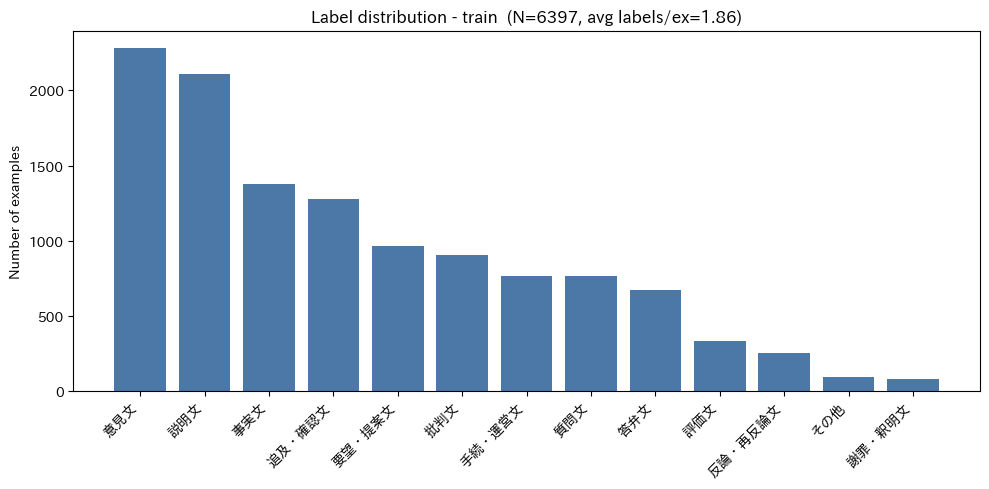

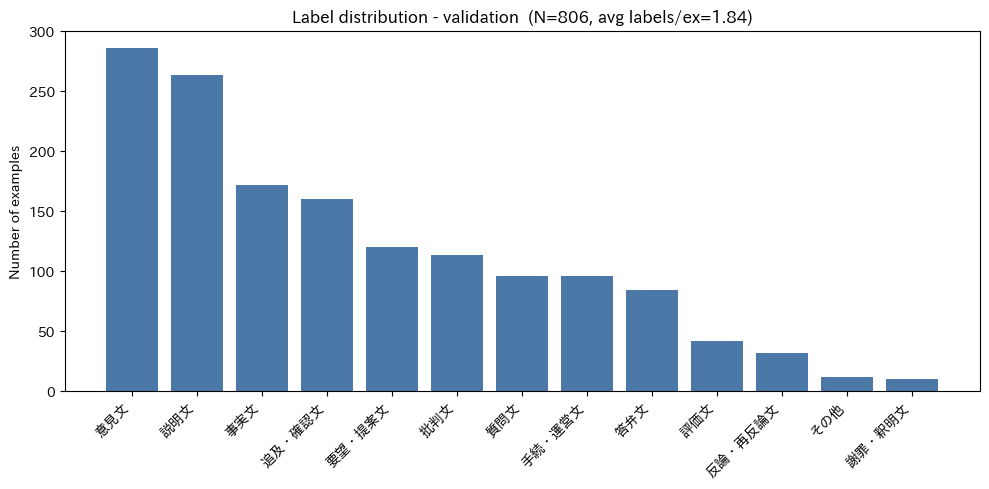

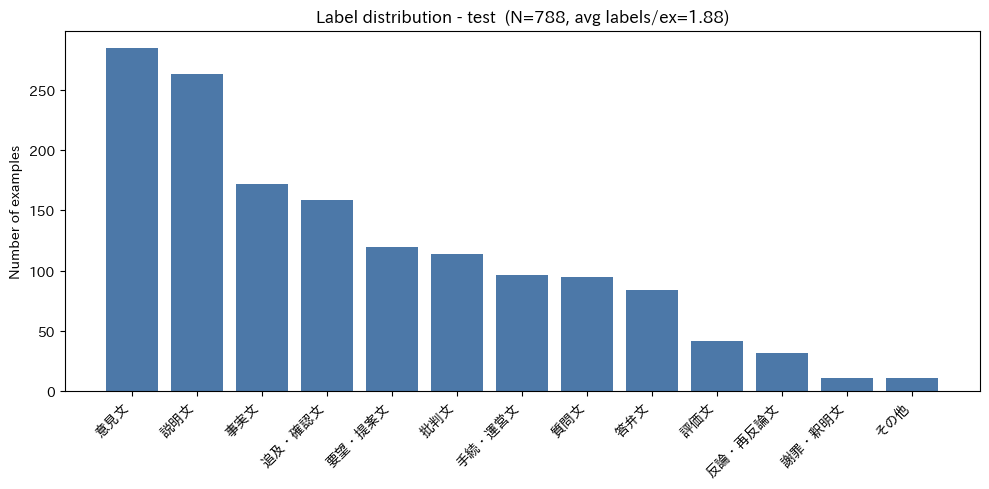

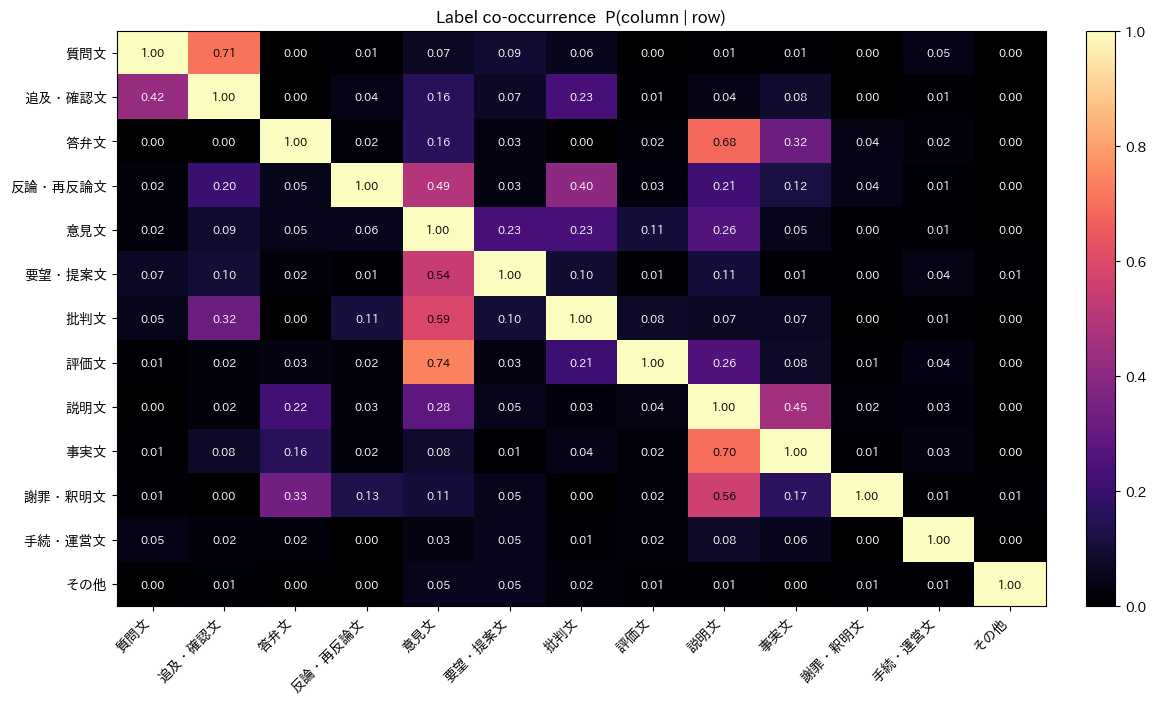

In [4]:
def iterative_stratification(y, proportions, seed=SEED):
    """Multi-label stratified partition (Sechidis et al., 2011).

    Splits sample indices into len(proportions) disjoint subsets while keeping
    each label's distribution close to the requested proportions. Plain random
    splitting can leave rare labels (e.g. 謝罪・釈明文) missing from val/test."""
    y = as_multihot(y)
    rng = np.random.RandomState(seed)
    n_samples = y.shape[0]
    subset_target = [p * n_samples for p in proportions]
    label_target = np.outer(proportions, y.sum(axis=0)).astype(float)
    subsets = [[] for _ in proportions]
    remaining = set(range(n_samples))

    while remaining:
        rem = np.fromiter(remaining, dtype=int)
        label_counts = y[rem].sum(axis=0)
        positive = np.where(label_counts > 0)[0]
        if positive.size == 0:  # leftover all-zero rows (none expected here)
            for i in rem:
                s = int(np.argmax(subset_target))
                subsets[s].append(int(i)); subset_target[s] -= 1; remaining.discard(int(i))
            break
        # Allocate the rarest remaining label first.
        l = int(positive[np.argmin(label_counts[positive])])
        samples = rem[y[rem, l] == 1]
        rng.shuffle(samples)
        for i in samples:
            i = int(i)
            col = label_target[:, l]
            cand = np.where(col == col.max())[0]
            if cand.size > 1:  # tie-break on overall subset capacity
                st = np.array(subset_target)[cand]
                cand = cand[np.where(st == st.max())[0]]
            s = int(cand[0]) if cand.size == 1 else int(cand[rng.randint(cand.size)])
            subsets[s].append(i)
            label_target[s] -= y[i]
            subset_target[s] -= 1
            remaining.discard(i)
    return subsets


full = Dataset.from_json(DIET_PROCESSED_PATH)
y_all = np.array(full["label"])
print(f"Loaded {len(full)} examples with {y_all.shape[1]} labels.")

props = [SPLIT_FRACTIONS["train"], SPLIT_FRACTIONS["validation"], SPLIT_FRACTIONS["test"]]
train_idx, val_idx, test_idx = iterative_stratification(y_all, props, seed=SEED)

ds = DatasetDict({
    "train": full.select(sorted(train_idx)),
    "validation": full.select(sorted(val_idx)),
    "test": full.select(sorted(test_idx)),
}).rename_column("label", "labels")
for split in ds:
    print(f"{split}: {len(ds[split])} examples")

# Sanity-check the split: every label should appear in every split.
for split in ["train", "validation", "test"]:
    plot_label_distribution(ds[split]["labels"], PARLIAMENT_SPEECH_LABELS,
                            title=f"Label distribution - {split}")
plot_label_cooccurrence(np.array(ds["train"]["labels"]), PARLIAMENT_SPEECH_LABELS)

## 5. Tokenize, build the LoRA model, and train

In [5]:
# --- Tokenize ---
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=False)


def tokenize(batch):
    enc = tokenizer(batch["text"], truncation=True, max_length=MAX_LEN)
    enc["labels"] = [[float(x) for x in row] for row in batch["labels"]]
    return enc


tokenized = ds.map(tokenize, batched=True, remove_columns=["text", "text_label"])
features = tokenized["train"].features.copy()
features["labels"] = Sequence(Value("float32"), length=len(PARLIAMENT_SPEECH_LABELS))
tokenized = tokenized.cast(features)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# --- Handle class imbalance: positive weights for BCE (from TRAIN only) ---
y_train = as_multihot(ds["train"]["labels"])
pos = y_train.sum(axis=0)
neg = y_train.shape[0] - pos
pos_weight = torch.tensor(np.clip(neg / np.clip(pos, 1, None), 1.0, 10.0), dtype=torch.float)
print("pos_weight:", {lab: round(w, 2) for lab, w in zip(PARLIAMENT_SPEECH_LABELS, pos_weight.tolist())})

# --- Base model + LoRA adapter ---
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(PARLIAMENT_SPEECH_LABELS),
    problem_type="multi_label_classification",
    id2label={i: lab for i, lab in enumerate(PARLIAMENT_SPEECH_LABELS)},
    label2id={lab: i for i, lab in enumerate(PARLIAMENT_SPEECH_LABELS)},
)
model = get_peft_model(model, LORA_CONFIG)
model.print_trainable_parameters()


class MultiLabelTrainer(Trainer):
    """Trainer with class-weighted BCE loss for imbalanced multi-label data."""

    def __init__(self, *args, pos_weight=None, **kwargs):
        super().__init__(*args, **kwargs)
        self._pos_weight = pos_weight

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        pw = self._pos_weight.to(outputs.logits.device) if self._pos_weight is not None else None
        loss = torch.nn.functional.binary_cross_entropy_with_logits(
            outputs.logits, labels.float(), pos_weight=pw)
        return (loss, outputs) if return_outputs else loss


def compute_metrics(eval_pred):
    metrics, _ = compute_multilabel_metrics(sigmoid(eval_pred.predictions), eval_pred.label_ids, thresholds=0.5)
    return metrics


args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    learning_rate=1e-4,                # higher LR is typical for LoRA adapters
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=15,
    weight_decay=0.01,
    warmup_ratio=0.1,
    lr_scheduler_type="cosine",
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    logging_steps=25,
    fp16=USE_FP16,
    report_to="none",
    seed=SEED,
)

trainer = MultiLabelTrainer(
    model=model,
    args=args,
    train_dataset=tokenized["train"],
    eval_dataset=tokenized["validation"],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    pos_weight=pos_weight,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
)

trainer.train()
print("Best-model validation metrics:", trainer.evaluate())

Casting the dataset: 100%|██████████| 788/788 [00:00<00:00, 46135.00 examples/s]


pos_weight: {'質問文': 7.38, '追及・確認文': 4.01, '答弁文': 8.48, '反論・再反論文': 10.0, '意見文': 1.8, '要望・提案文': 5.65, '批判文': 6.05, '評価文': 10.0, '説明文': 2.04, '事実文': 3.66, '謝罪・釈明文': 10.0, '手続・運営文': 7.33, 'その他': 10.0}


Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at ku-nlp/deberta-v3-base-japanese and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


trainable params: 3,254,797 || all params: 163,725,338 || trainable%: 1.9880


The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 96868, 'bos_token_id': 96871, 'pad_token_id': 96869}.


Epoch,Training Loss,Validation Loss,F1 Micro,F1 Macro,F1 Weighted,Precision Micro,Recall Micro,Pr Auc Macro
1,0.659600,0.622106,0.582946,0.473150,0.607728,0.457614,0.802826,0.524768
2,0.542500,0.495047,0.650713,0.537641,0.668549,0.541872,0.814266,0.625523
3,0.483800,0.455871,0.652252,0.584205,0.685886,0.528137,0.852624,0.680780
4,0.439800,0.455356,0.679763,0.611743,0.696116,0.566368,0.849933,0.697858
5,0.342400,0.461803,0.690141,0.639427,0.703048,0.593508,0.824361,0.712013
6,0.340000,0.472524,0.690429,0.638840,0.704030,0.592200,0.827725,0.714524
7,0.304700,0.508008,0.703278,0.644772,0.715085,0.613956,0.823015,0.725916
8,0.259300,0.556562,0.716857,0.655063,0.720880,0.646645,0.804172,0.716415
9,0.283300,0.576135,0.717229,0.656386,0.721774,0.644659,0.808210,0.719982
10,0.231700,0.576980,0.719762,0.659771,0.725082,0.644492,0.814939,0.718047


Best-model validation metrics: {'eval_loss': 0.615955650806427, 'eval_f1_micro': 0.7285285285285286, 'eval_f1_macro': 0.6747349357789048, 'eval_f1_weighted': 0.7325077642918445, 'eval_precision_micro': 0.6578091106290672, 'eval_recall_micro': 0.8162853297442799, 'eval_pr_auc_macro': 0.72068062828644, 'eval_runtime': 4.4688, 'eval_samples_per_second': 180.363, 'eval_steps_per_second': 5.818, 'epoch': 15.0}


## 6. Tune per-class thresholds on the validation set

In [6]:
val_pred = trainer.predict(tokenized["validation"])
val_probs = sigmoid(val_pred.predictions)
val_true = as_multihot(val_pred.label_ids)

thresholds = tune_thresholds(val_probs, val_true)
print("Tuned per-class thresholds:")
for lab, t in zip(PARLIAMENT_SPEECH_LABELS, thresholds):
    print(f"  {lab}: {t:.2f}")

base, _ = compute_multilabel_metrics(val_probs, val_true, thresholds=0.5)
tuned, _ = compute_multilabel_metrics(val_probs, val_true, thresholds=thresholds)
print(f"\nValidation f1_macro @0.5   : {base['f1_macro']:.4f}")
print(f"Validation f1_macro tuned  : {tuned['f1_macro']:.4f}")

Tuned per-class thresholds:
  質問文: 0.90
  追及・確認文: 0.70
  答弁文: 0.95
  反論・再反論文: 0.60
  意見文: 0.65
  要望・提案文: 0.85
  批判文: 0.85
  評価文: 0.55
  説明文: 0.50
  事実文: 0.75
  謝罪・釈明文: 0.75
  手続・運営文: 0.75
  その他: 0.60

Validation f1_macro @0.5   : 0.6747
Validation f1_macro tuned  : 0.6964


## 7. Evaluate on the held-out test set (with heatmaps)

=== Test metrics (tuned thresholds) ===
  f1_micro: 0.7400
  f1_macro: 0.6709
  f1_weighted: 0.7422
  precision_micro: 0.7295
  recall_micro: 0.7507
  pr_auc_macro: 0.7053

Per-class classification report:
              precision    recall  f1-score   support

         質問文       0.80      0.82      0.81        95
      追及・確認文       0.71      0.76      0.74       159
         答弁文       0.65      0.62      0.63        84
     反論・再反論文       0.31      0.41      0.35        32
         意見文       0.83      0.78      0.81       285
      要望・提案文       0.69      0.68      0.69       120
         批判文       0.74      0.66      0.69       114
         評価文       0.46      0.60      0.52        42
         説明文       0.75      0.83      0.79       263
         事実文       0.75      0.76      0.75       172
      謝罪・釈明文       0.31      0.45      0.37        11
      手続・運営文       0.85      0.86      0.86        96
         その他       0.64      0.82      0.72        11

   micro avg       0.73      0.75   

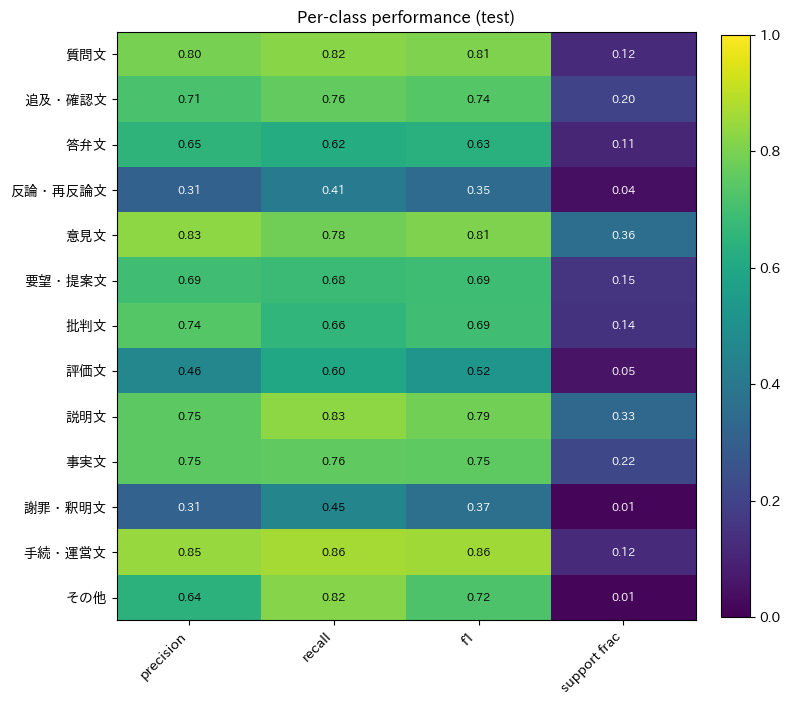

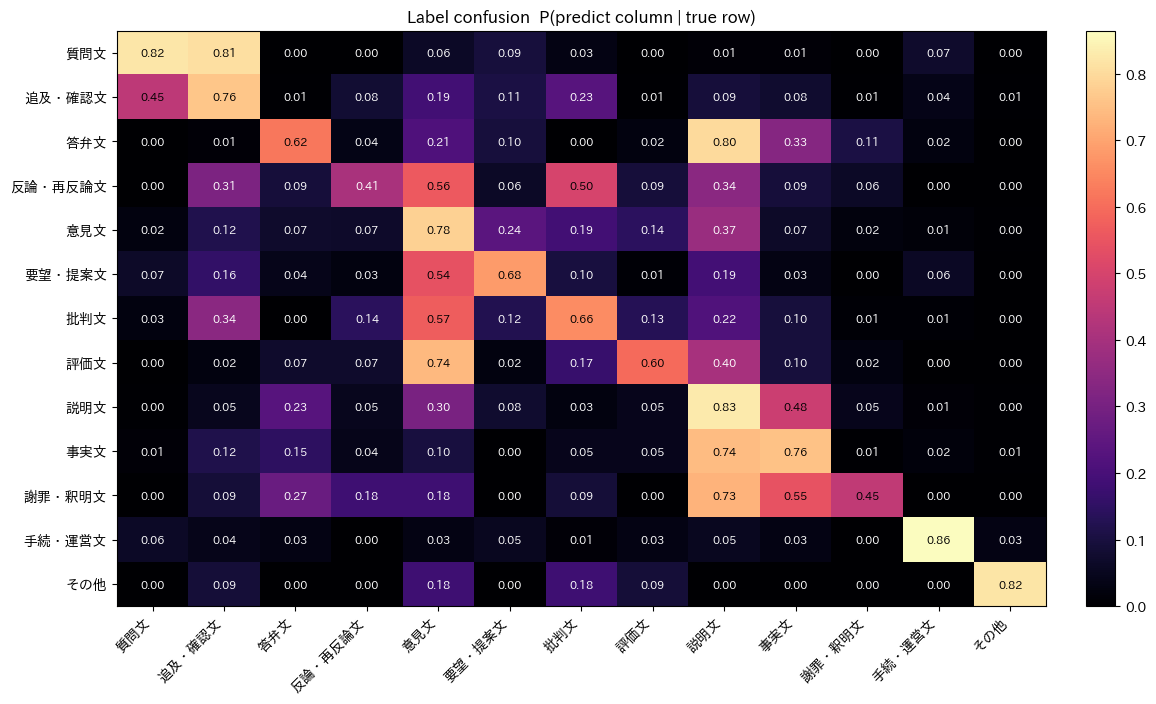

In [7]:
test_pred = trainer.predict(tokenized["test"])
test_probs = sigmoid(test_pred.predictions)
test_true = as_multihot(test_pred.label_ids)

metrics, test_preds = compute_multilabel_metrics(test_probs, test_true, thresholds=thresholds)
print("=== Test metrics (tuned thresholds) ===")
for k, v in metrics.items():
    print(f"  {k}: {v:.4f}")

print("\nPer-class classification report:")
print(classification_report(test_true, test_preds,
                            target_names=PARLIAMENT_SPEECH_LABELS, zero_division=0))

# Requested heatmaps: per-class performance and label-confusion.
plot_per_class_performance(test_true, test_preds, PARLIAMENT_SPEECH_LABELS)
plot_label_confusion(test_true, test_preds, PARLIAMENT_SPEECH_LABELS)

## 8. Save the final model + thresholds

In [8]:
run_dir = os.path.join(OUTPUT_DIR, datetime.datetime.now().strftime("%Y%m%d_%H%M%S"))
os.makedirs(run_dir, exist_ok=True)

# Merge the LoRA adapter into the base weights so the artifact loads as a plain
# AutoModelForSequenceClassification for inference.
merged = model.merge_and_unload()
merged.save_pretrained(run_dir)
tokenizer.save_pretrained(run_dir)

with open(os.path.join(run_dir, "thresholds.json"), "w", encoding="utf-8") as f:
    json.dump({"labels": PARLIAMENT_SPEECH_LABELS,
               "thresholds": [float(t) for t in thresholds]}, f, ensure_ascii=False, indent=2)

print("Saved model + thresholds to", run_dir)

Saved model + thresholds to /root/projects/kokkai_analysis/data/params/../data/finetuned_text_labeller_parliament/20260612_180604


## (Optional) YouTube comment classifier — full fine-tune

In [ ]:
import os
import numpy as np
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
)
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

YOUTUBE_DATA_PROCESSED_PATH = os.path.join(DATA_DIR, "youtube_label", "vector_label_youtube_segment.jsonl")

if False:
    ds_yt = Dataset.from_json(YOUTUBE_DATA_PROCESSED_PATH).train_test_split(test_size=0.2, seed=42)
    ds_yt = ds_yt.rename_column("label", "labels")
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=False)
    MAX_LEN = 256

    def onehot_to_id(v):
        v = np.asarray(v)
        if v.sum() != 1:
            raise ValueError(f"Not a single-class one-hot label: sum={v.sum()}, v={v}")
        return v.argmax()

    def tok(batch):
        out = tokenizer(batch["text"], truncation=True, max_length=MAX_LEN)
        out["labels"] = [onehot_to_id(v) for v in batch["labels"]]
        return out

    ds_yt = ds_yt.map(tok, batched=True, remove_columns=["text", "text_label"])

    num_labels = 2
    model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=num_labels)
    model.config.id2label = {i: lab for i, lab in enumerate(["政治", "その他"])}
    model.config.label2id = {lab: i for i, lab in enumerate(["政治", "その他"])}

    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        preds = np.argmax(logits, axis=-1)
        return {
            "accuracy": accuracy_score(labels, preds),
            "f1_macro": f1_score(labels, preds, average="macro", zero_division=0),
        }

    args = TrainingArguments(
        output_dir=os.path.join(DATA_DIR, "finetuned_text_labeller_youtube"),
        learning_rate=2e-5,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=32,
        num_train_epochs=5,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="f1_macro",
        greater_is_better=True,
    )
    trainer = Trainer(
        model=model, args=args,
        train_dataset=ds_yt["train"], eval_dataset=ds_yt["test"],
        processing_class=tokenizer,
        data_collator=DataCollatorWithPadding(tokenizer=tokenizer),
        compute_metrics=compute_metrics,
    )
    trainer.train()
    OUT_DIR = os.path.join(DATA_DIR, "finetuned_text_labeller_youtube", "final")
    trainer.save_model(OUT_DIR)
    tokenizer.save_pretrained(OUT_DIR)

## (Optional) Twitter classifier — full fine-tune

In [ ]:
import os
import numpy as np
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
)
from sklearn.metrics import accuracy_score, f1_score

TWITTER_DATA_PROCESSED_PATH = os.path.join(DATA_DIR, "tweet_label", "vector_label_tweet_label.jsonl")

if False:
    ds_tw = Dataset.from_json(TWITTER_DATA_PROCESSED_PATH).train_test_split(test_size=0.2, seed=42)
    ds_tw = ds_tw.rename_column("label", "labels")
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=False)
    MAX_LEN = 256

    def onehot_to_id(v):
        v = np.asarray(v)
        if v.sum() != 1:
            raise ValueError(f"Not a single-class one-hot label: sum={v.sum()}, v={v}")
        return 1 if v.argmax() >= 1 else 0

    def tok(batch):
        out = tokenizer(batch["text"], truncation=True, max_length=MAX_LEN)
        out["labels"] = [onehot_to_id(v) for v in batch["labels"]]
        return out

    ds_tw = ds_tw.map(tok, batched=True, remove_columns=["text", "text_label"])

    num_labels = 2
    model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=num_labels)
    model.config.id2label = {i: lab for i, lab in enumerate(["政治", "その他"])}
    model.config.label2id = {lab: i for i, lab in enumerate(["政治", "その他"])}

    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        preds = np.argmax(logits, axis=-1)
        return {
            "accuracy": accuracy_score(labels, preds),
            "f1_macro": f1_score(labels, preds, average="macro", zero_division=0),
        }

    args = TrainingArguments(
        output_dir=os.path.join(DATA_DIR, "finetuned_text_labeller_twitter"),
        learning_rate=2e-5,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=32,
        num_train_epochs=5,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="f1_macro",
        greater_is_better=True,
    )
    trainer = Trainer(
        model=model, args=args,
        train_dataset=ds_tw["train"], eval_dataset=ds_tw["test"],
        processing_class=tokenizer,
        data_collator=DataCollatorWithPadding(tokenizer=tokenizer),
        compute_metrics=compute_metrics,
    )
    trainer.train()
    OUT_DIR = os.path.join(DATA_DIR, "finetuned_text_labeller_twitter", "final")
    trainer.save_model(OUT_DIR)
    tokenizer.save_pretrained(OUT_DIR)

## (Optional) Upload trained models to the Hugging Face Hub

In [ ]:
import os
from transformers import AutoConfig
from huggingface_hub import create_repo, upload_folder

BASE_MODEL = "ku-nlp/deberta-v3-base-japanese"
REPO_ID = "kkatodus"

REPO_NAMES = [
    "text_labeller_parliament-deberta-v3-base-japanese",
    "text_labeller_youtube-full-deberta-v3-base-japanese",
    "text_labeller_twitter-full-deberta-v3-base-japanese",
]
DIRECTORIES = [
    "finetuned_text_labeller_parliament/final/",
    "finetuned_text_labeller_youtube/final/",
    "finetuned_text_labeller_twitter/final/",
]
LABELS_LIST = [
    PARLIAMENT_SPEECH_LABELS,
    ["政治", "その他"],
    ["政治", "その他"],
]

if False:
    for repo_name, ckpt_dir, labels in zip(REPO_NAMES, DIRECTORIES, LABELS_LIST):
        print(f"Processing {repo_name} from {ckpt_dir} with {len(labels)} labels...")
        local_path = os.path.join(DATA_DIR, ckpt_dir)

        config = AutoConfig.from_pretrained(BASE_MODEL)
        config.id2label = {i: lab for i, lab in enumerate(labels)}
        config.label2id = {lab: i for i, lab in enumerate(labels)}
        config.num_labels = len(labels)
        if "twitter" not in repo_name and "youtube" not in repo_name:
            config.problem_type = "multi_label_classification"
        config.save_pretrained(local_path)

        create_repo(repo_id=f"{REPO_ID}/{repo_name}", exist_ok=True)
        upload_folder(repo_id=f"{REPO_ID}/{repo_name}", folder_path=local_path, repo_type="model")

## 9. Inference: label new speech segments

Loads the saved merged model + tuned thresholds and classifies arbitrary text.
Run section 8 first (or set `MODEL_DIR` to an existing run directory).

In [ ]:
import os
import json
import glob
import numpy as np
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# Pick the most recent saved run, or set MODEL_DIR manually.
run_dirs = sorted(glob.glob(os.path.join(OUTPUT_DIR, "[0-9]" * 8 + "_" + "[0-9]" * 6)))
MODEL_DIR = run_dirs[-1] if run_dirs else os.path.join(OUTPUT_DIR, "final")
print("Loading model from:", MODEL_DIR)

infer_tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR, use_fast=False)
infer_model = AutoModelForSequenceClassification.from_pretrained(MODEL_DIR).eval()
infer_device = "cuda" if torch.cuda.is_available() else "cpu"
infer_model.to(infer_device)

# Per-class thresholds saved during training (fall back to 0.5).
thr_path = os.path.join(MODEL_DIR, "thresholds.json")
if os.path.exists(thr_path):
    saved = json.load(open(thr_path, encoding="utf-8"))
    INFER_LABELS, INFER_THRESHOLDS = saved["labels"], np.array(saved["thresholds"])
else:
    INFER_LABELS = [infer_model.config.id2label[i] for i in range(infer_model.config.num_labels)]
    INFER_THRESHOLDS = np.full(len(INFER_LABELS), 0.5)


@torch.no_grad()
def predict_labels(texts, threshold=None, max_len=MAX_LEN):
    """Return predicted labels + per-class probabilities for speech segments."""
    if isinstance(texts, str):
        texts = [texts]
    thr = INFER_THRESHOLDS if threshold is None else np.full(len(INFER_LABELS), threshold)
    enc = infer_tokenizer(texts, truncation=True, max_length=max_len,
                          padding=True, return_tensors="pt").to(infer_device)
    probs = torch.sigmoid(infer_model(**enc).logits).cpu().numpy()
    results = []
    for p in probs:
        chosen = [INFER_LABELS[i] for i in range(len(INFER_LABELS)) if p[i] >= thr[i]]
        if not chosen:  # always return the single most likely label
            chosen = [INFER_LABELS[int(p.argmax())]]
        scores = {INFER_LABELS[i]: round(float(p[i]), 3) for i in range(len(INFER_LABELS))}
        results.append({"labels": chosen,
                        "scores": dict(sorted(scores.items(), key=lambda kv: -kv[1]))})
    return results


examples = [
    "この法案について政府の見解を伺います。",
    "委員長、議事進行について申し上げます。",
    "私はこの政策には断固反対であり、極めて遺憾だと考えます。",
]
for ex, res in zip(examples, predict_labels(examples)):
    top3 = list(res["scores"].items())[:3]
    print(f"\n{ex}\n  -> {res['labels']}  (top: {top3})")